In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## lets load the data ##

In [46]:
df = pd.read_csv("apartment_rent_data.csv")
df.head()

,id,city,locality,apartment_type,area_sqft,bedrooms,bathrooms,floor_number,total_floors,age_of_building,...,parking_available,gym,swimming_pool,distance_to_metro_km,distance_to_school_km,distance_to_hospital_km,crime_rate_index,air_quality_index,avg_nearby_rent,monthly_rent
0,1,Mumbai,Andheri West,2BHK,850,2,2,5,12,8,...,1,1,0,1.2,0.8,2.1,3,87,28000,32000
1,2,Mumbai,Bandra,3BHK,1200,3,2,8,15,5,...,1,1,1,0.5,1.2,1.8,2,91,45000,55000
2,3,Mumbai,Kurla,1BHK,480,1,1,2,7,15,...,0,0,0,2.8,1.5,3.2,6,72,14000,13500
3,4,Pune,Koregaon Park,2BHK,920,2,2,3,10,3,...,1,1,1,3.5,0.6,1.5,2,95,22000,27000
4,5,Pune,Hadapsar,1BHK,520,1,1,4,8,10,...,1,0,0,5.2,1.8,2.8,4,78,10000,11500


In [47]:
df.keys()

Index(['id', 'city', 'locality', 'apartment_type', 'area_sqft', 'bedrooms',
       'bathrooms', 'floor_number', 'total_floors', 'age_of_building',
       'furnished_status', 'parking_available', 'gym', 'swimming_pool',
       'distance_to_metro_km', 'distance_to_school_km',
       'distance_to_hospital_km', 'crime_rate_index', 'air_quality_index',
       'avg_nearby_rent', 'monthly_rent'],
      dtype='str')

In [48]:
#lets check the descrription of the data
print(df.monthly_rent.describe())

count      120.000000
mean     26989.166667
std      12827.018463
min       7000.000000
25%      19375.000000
50%      24750.000000
75%      33625.000000
max      82000.000000
Name: monthly_rent, dtype: float64


In [49]:
df.isnull().sum()

id                         0
city                       0
locality                   0
apartment_type             0
area_sqft                  0
bedrooms                   0
bathrooms                  0
floor_number               0
total_floors               0
age_of_building            0
furnished_status           0
parking_available          0
gym                        0
swimming_pool              0
distance_to_metro_km       0
distance_to_school_km      0
distance_to_hospital_km    0
crime_rate_index           0
air_quality_index          0
avg_nearby_rent            0
monthly_rent               0
dtype: int64

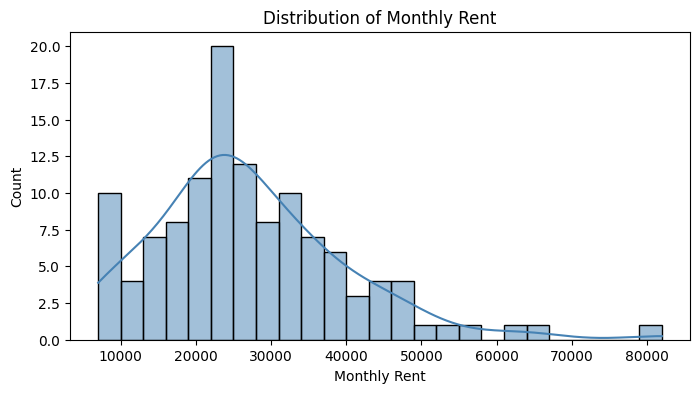

In [50]:
# Distribution of target variable
plt.figure(figsize=(8, 4))
sns.histplot(df['monthly_rent'], bins=25, kde=True, color='steelblue')
plt.title('Distribution of Monthly Rent')
plt.xlabel('Monthly Rent')
plt.show()

/var/folders/59/gd4r48jx5vb_g3bgqgc0qdmw0000gn/T/ipykernel_5946/2190594438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y='monthly_rent', data=df, palette='Set2')


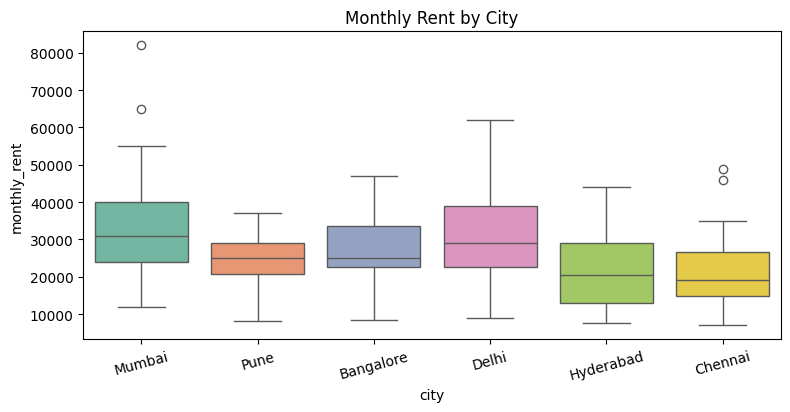

In [51]:
# --- Rent by city ---
plt.figure(figsize=(9, 4))
sns.boxplot(x='city', y='monthly_rent', data=df, palette='Set2')
plt.title('Monthly Rent by City')
plt.xticks(rotation=15) #sets the x values so that they not overlap with names (degree)
plt.show()

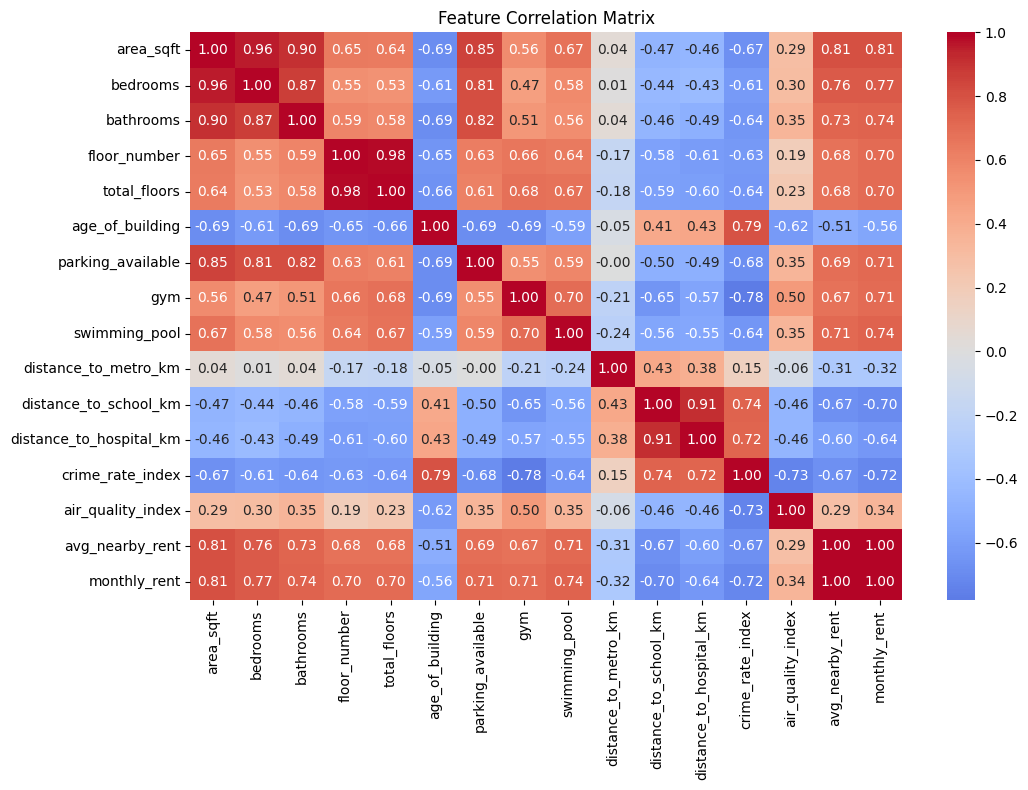

In [52]:
# --- Correlation heatmap (numeric columns only) ---
plt.figure(figsize=(11, 8))
num_df = df.select_dtypes(include='number').drop('id', axis=1) #includes only numeric values
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


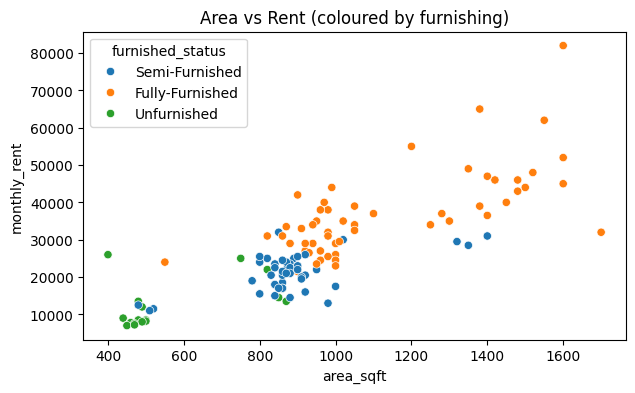

In [56]:
# --- Area vs Rent ---
plt.figure(figsize=(7, 4))
sns.scatterplot(x='area_sqft', y='monthly_rent', hue='furnished_status', data=df)
plt.title('Area vs Rent (coloured by furnishing)')
plt.show()

In [53]:
# Drop columns based on heatmap analysis
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

# Step 1 — drop columns decided from heatmap analysis
cols_to_drop = [
    'id', 'locality', 'bedrooms', 'bathrooms',
    'floor_number', 'total_floors', 'distance_to_hospital_km'
]
df_model = df.drop(cols_to_drop, axis=1)

print("Remaining features:", df_model.columns.tolist())
print("Shape:", df_model.shape)
# Should be (120, 10) — 9 features + 1 target

Remaining features: ['city', 'apartment_type', 'area_sqft', 'age_of_building', 'furnished_status', 'parking_available', 'gym', 'swimming_pool', 'distance_to_metro_km', 'distance_to_school_km', 'crime_rate_index', 'air_quality_index', 'avg_nearby_rent', 'monthly_rent']
Shape: (120, 14)


In [54]:
cat_cols = ['city', 'apartment_type', 'furnished_status']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

In [55]:
print(df_model.dtypes)
print("\nAny non-numeric columns?", 
      df_model.select_dtypes(include='object').columns.tolist())

city                       int64
apartment_type             int64
area_sqft                  int64
age_of_building            int64
furnished_status           int64
parking_available          int64
gym                        int64
swimming_pool              int64
distance_to_metro_km     float64
distance_to_school_km    float64
crime_rate_index           int64
air_quality_index          int64
avg_nearby_rent            int64
monthly_rent               int64
dtype: object

Any non-numeric columns? []


In [43]:
from sklearn.model_selection import train_test_split

X = df_model.drop('monthly_rent', axis=1)
y = df_model['monthly_rent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()                         
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nScaling done!")
print("X_train_scaled shape:", X_train_scaled.shape)


Scaling done!
X_train_scaled shape: (96, 13)
